In [24]:
import os
from pathlib import Path
# 現在の作業ディレクトリを確認し、'Scripts' にいる場合は親ディレクトリに移動
current_dir = Path.cwd()
if current_dir.name == "Scripts":
    os.chdir(current_dir.parent)
print(f"Current working directory: {Path.cwd()}")

Current working directory: c:\Users\sryoh\Documents\Python_MSSE_analysis


           No Group  Time   Freezing
0    100FCMOE   MOE     1   0.000000
1    100FCMOE   MOE     2   0.000000
2    100FCMOE   MOE     3   0.000000
3    100FCMOE   MOE     4  47.600000
4    100FCMOE   MOE     5  43.500000
..        ...   ...   ...        ...
139   99FCMOE   MOE     2   0.000000
140   99FCMOE   MOE     3   0.000000
141   99FCMOE   MOE     4  14.566667
142   99FCMOE   MOE     5  60.800000
143   99FCMOE   MOE     6  71.966667

[144 rows x 4 columns]


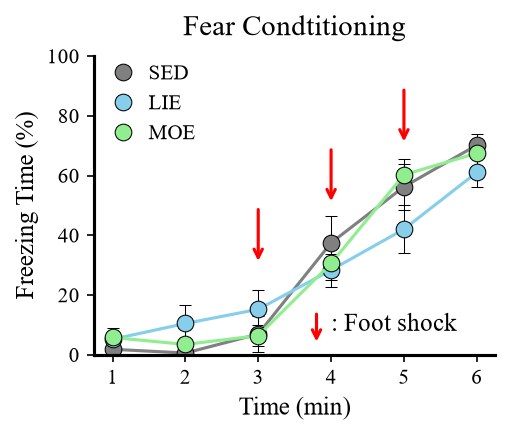

=== Contextual Fear Conditioning: anovakun 完全互換 統合統計解析レポート ===

<< 記述統計量 (Descriptive Statistics) >>
Group  n      Mean        SD
  SED  8  1.837500  2.097045
  SED  8  0.570833  1.196747
  SED  8  6.908333 17.399824
  SED  8 37.462500 25.035590
  SED  8 56.241667 21.661888
  SED  8 70.179167 10.403005
  LIE  8  5.179167  8.203463
  LIE  8 10.462500 17.141951
  LIE  8 15.212500 18.390206
  LIE  8 28.345833 15.690629
  LIE  8 42.041667 22.621578
  LIE  8 61.050000 13.926029
  MOE  8  5.787500  8.729951
  MOE  8  3.445833  4.883335
  MOE  8  6.395833  9.729458
  MOE  8 30.591667 16.155914
  MOE  8 60.258333 15.204383
  MOE  8 67.470833 12.717610

<< 1. 混合二元配置分散分析 (Mixed 2-way ANOVA: Group x Time) >>
     Source           SS  DF1  DF2           MS         F        p_unc    p_GG_corr      np2      eps sphericity  W_spher  p_spher
      Group   113.542654    2   21    56.771327  0.149701 8.618761e-01          NaN 0.014057      NaN        NaN      NaN      NaN
       Time 84911.381358    5  

'=====================================================================================\n=== Contextual Fear Conditioning: anovakun 完全互換 統合統計解析レポート ===\n=====================================================================================\n\n<< 記述統計量 (Descriptive Statistics) >>\nGroup  n      Mean        SD\n  SED  8  1.837500  2.097045\n  SED  8  0.570833  1.196747\n  SED  8  6.908333 17.399824\n  SED  8 37.462500 25.035590\n  SED  8 56.241667 21.661888\n  SED  8 70.179167 10.403005\n  LIE  8  5.179167  8.203463\n  LIE  8 10.462500 17.141951\n  LIE  8 15.212500 18.390206\n  LIE  8 28.345833 15.690629\n  LIE  8 42.041667 22.621578\n  LIE  8 61.050000 13.926029\n  MOE  8  5.787500  8.729951\n  MOE  8  3.445833  4.883335\n  MOE  8  6.395833  9.729458\n  MOE  8 30.591667 16.155914\n  MOE  8 60.258333 15.204383\n  MOE  8 67.470833 12.717610\n\n<< 1. 混合二元配置分散分析 (Mixed 2-way ANOVA: Group x Time) >>\n     Source           SS  DF1  DF2           MS         F        p_unc    p_GG_corr      np2  

In [40]:
# Fear Conditioning のデータ分析
from Scripts.Create_Dataset import read_freezing_data
from Scripts.Create_Plots import _apply_axis_style, _make_legend_handles, plot_save
from Scripts.Statistical_Analysis import generate_anovakun_report
from pathlib import Path
import matplotlib.pyplot as plt

# データの読み込み
data_FC = read_freezing_data(
  files=sorted(Path("FC").glob("*.xls")),
  type="FC"
)
print(data_FC)

# 棒グラフの作成
figFC, axFC = plot_save(
    df=data_FC,
    title = "Fear Condtitioning",
    xticks=(1, 2, 3, 4, 5, 6),
    figsize=(3.5, 3),
    save_path=Path("Results/Plots/Fear_Conditioning.png"),
    method="matplotlib"
)

# Fear Conditioningのグラフに矢印を追加。
axFC.annotate(
    "",
    xy=(3, 30), xytext=(3, 50), # 矢印の先端と始点の座標を指定
    arrowprops={"arrowstyle": "->", "color": "red", "lw": 1.5} # 矢印のスタイルを指定
)
axFC.annotate(
    "",
    xy=(4, 50), xytext=(4, 70),
    arrowprops={"arrowstyle": "->", "color": "red", "lw": 1.5}
)
axFC.annotate(
    "",
    xy=(5, 70), xytext=(5, 90),
    arrowprops={"arrowstyle": "->", "color": "red", "lw": 1.5}
)
axFC.annotate(
    "",
    xy=(3.8, 3), xytext=(3.8, 15),
    arrowprops={"arrowstyle": "->", "color": "red", "lw": 1.5}
)
axFC.text(
    4.0, 8, ": Foot shock", # テキストの座標と内容を指定
    fontsize=12,
    fontfamily="Times New Roman",
    color="black"
)

# 保存
# 保存するファイルパスを指定、拡張子を変更することで、PDFやSVGなどの形式でも保存可能
output_path = "Results/Plots/Fear_Conditioning_matplotlib.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight") # 解像度と余白を指定して保存

# グラフを表示
plt.show()

# 統計解析
generate_anovakun_report(
  data=data_FC,
  title="Contextual Fear Conditioning",
  filename="Anovakun_Like_Analysis_FC.txt"
)